In [1]:
import sys
print(sys.executable)

d:\AI-MLTraining\machine_learning\venv\Scripts\python.exe


In [2]:
import numpy as np 
print(f"NumPy Version: {np.__version__}")


NumPy Version: 1.26.4


In [3]:
import tensorflow as tf
print(f"tensorflow Version: {tf.__version__}")


tensorflow Version: 2.15.0


In [4]:
import tensorflow as tf
import keras

print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")

TensorFlow Version: 2.15.0
Keras Version: 2.15.0


In [5]:
import numpy as np
import pandas as pd
import tensorflow


In [6]:
df=pd.read_csv("Churn_Modelling.csv")

In [7]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
df.shape

(10000, 14)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [10]:
df.duplicated().sum()

0

In [11]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [12]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [13]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'],inplace=True)

In [14]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [15]:
print(df.columns)

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')


In [16]:
df=pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True, dtype=int)

In [17]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,0,1


In [18]:
X = df.drop(columns=['Exited'])
y = df['Exited']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [19]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,0,1


In [20]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [22]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [24]:
model = Sequential()#we would make sequential type  models 
#making and obj of sequential data 

In [34]:
"""model.add(Dense(3,activation='sigmoid',input_dim = 11))#nodes of hidden layer,no of input=11
model.add(Dense(1,activation='sigmoid'))#output layer"""
model.add(Dense(11,activation='relu',input_dim = 11))
model.add(Dense(11,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [26]:
model.summary()#gives summary to your moidel 

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 3)                 36        
                                                                 
 dense_1 (Dense)             (None, 1)                 4         
                                                                 
Total params: 40 (160.00 Byte)
Trainable params: 40 (160.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [27]:
model.compile(loss='binary_crossentropy', optimizer='Adam',metrics=['accuracy'])#optimizer is to reduce weight
#metrics accuracy tells how to measue performance

In [35]:
history=model.fit(X_train_scaled,y_train,epochs=100,validation_split=0.2)#validationsplit 20 % of the data will be used for testing

Epoch 1/100
200/200 [==============================] - 1s 5ms/step - loss: 0.3786 - accuracy: 0.8475 - val_loss: 0.3813 - val_accuracy: 0.8400
Epoch 2/100
200/200 [==============================] - 1s 4ms/step - loss: 0.3783 - accuracy: 0.8477 - val_loss: 0.3809 - val_accuracy: 0.8394
Epoch 3/100
200/200 [==============================] - 1s 3ms/step - loss: 0.3779 - accuracy: 0.8473 - val_loss: 0.3805 - val_accuracy: 0.8400
Epoch 4/100
200/200 [==============================] - 1s 5ms/step - loss: 0.3777 - accuracy: 0.8470 - val_loss: 0.3803 - val_accuracy: 0.8400
Epoch 5/100
200/200 [==============================] - 1s 4ms/step - loss: 0.3775 - accuracy: 0.8475 - val_loss: 0.3799 - val_accuracy: 0.8394
Epoch 6/100
200/200 [==============================] - 1s 3ms/step - loss: 0.3772 - accuracy: 0.8480 - val_loss: 0.3795 - val_accuracy: 0.8394
Epoch 7/100
200/200 [==============================] - 1s 4ms/step - loss: 0.3769 - accuracy: 0.8480 - val_loss: 0.3792 - val_accuracy: 0.8406

In [29]:
#we will fetch weights and biases for 1 st layers
model.layers[0].get_weights()

[array([[ 0.10631165, -0.17932792, -0.16148332],
        [ 0.7398091 ,  3.6071365 , -0.2788225 ],
        [ 0.18825638,  0.02513319,  0.06914292],
        [ 0.61223936,  0.09484611, -0.4129441 ],
        [ 3.481502  ,  0.70851606, -0.92835444],
        [ 0.2223362 ,  0.08995611,  0.08585604],
        [ 0.7624132 ,  0.56672066,  1.7242272 ],
        [-0.09953078, -0.21145047, -0.27307573],
        [-0.5555022 ,  0.11872355, -0.78034097],
        [ 0.13349976,  0.05317894, -0.18346618],
        [ 0.18011847, -0.04127688,  0.701094  ]], dtype=float32),
 array([ 1.19795  , -0.7763989,  0.838608 ], dtype=float32)]

In [30]:
#we will fetch weights and biases for next layers
model.layers[1].get_weights()

[array([[-2.04711  ],
        [ 2.7951016],
        [-1.8594717]], dtype=float32),
 array([-0.49364173], dtype=float32)]

In [31]:
y_log=model.predict(X_test_scaled)

63/63 [==============================] - 0s 2ms/step


In [32]:
y_pred=np.where(y_log>0.5,1,0)#if greater than 0.5 return 1 else 0

In [33]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8525

In [39]:
import matplotlib.pyplot as plt 

In [37]:
history.history

{'loss': [0.3785627782344818,
  0.378254234790802,
  0.3779492974281311,
  0.37771275639533997,
  0.3775065541267395,
  0.37722310423851013,
  0.376900851726532,
  0.37668704986572266,
  0.37640631198883057,
  0.3761710226535797,
  0.37591004371643066,
  0.37568965554237366,
  0.3754475712776184,
  0.3752729296684265,
  0.3750229775905609,
  0.374749094247818,
  0.37457093596458435,
  0.3743273913860321,
  0.37406134605407715,
  0.3739316165447235,
  0.37375637888908386,
  0.3734988272190094,
  0.373322457075119,
  0.37310802936553955,
  0.3728486895561218,
  0.3727218210697174,
  0.37245064973831177,
  0.37225231528282166,
  0.37209799885749817,
  0.37191593647003174,
  0.3717324137687683,
  0.37154799699783325,
  0.3713054358959198,
  0.3711027204990387,
  0.3709443211555481,
  0.3707670569419861,
  0.3706088960170746,
  0.3704422116279602,
  0.37017902731895447,
  0.3700825870037079,
  0.36986109614372253,
  0.36964139342308044,
  0.36944645643234253,
  0.36925628781318665,
  0.3691

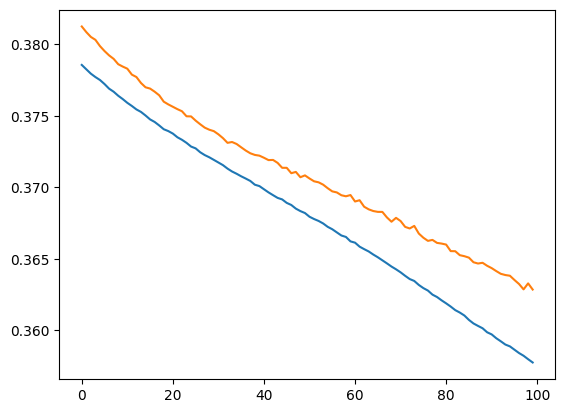

In [41]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

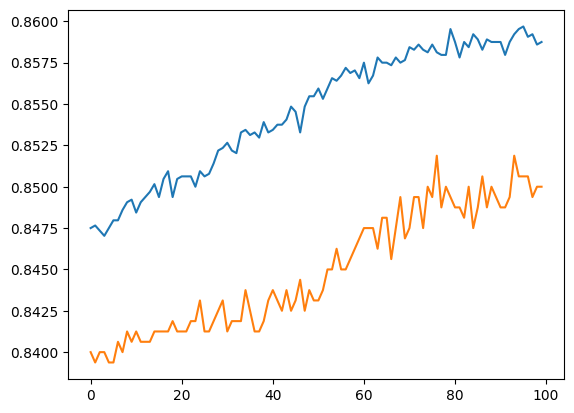

In [42]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])